Importing modules

In [16]:
import numpy as np
import matplotlib.pyplot as plt

Defining parameters

In [17]:


n_users = 35        # secondary users
n_primary = 8       # primary channels
n_channels = 40     # available spectrum bands

noise = 0.1         # noise for SINR

PS_penalty = 75     # penalty for primary-econdary user channel collision
SS_penalty = 45     # penalty for secondary-secondary user channel collision

N=20                # particles
S=n_channels-1      # search space [0, n_channels-1]
D=n_users           # dimensions = number of users
n_iter = 120        # number of updates of positions

a=0.7
b=1.5
b_hat=1.5
c=0.1

beta_start = 1
beta_end = 0.5




Getting SINR from random

In [18]:
# Simulate channel gains randomly (in reality this comes from pathloss model)
# SINR[i][j] = signal quality if user i uses channel j
np.random.seed(67)
channel_gain = np.random.uniform(0.1, 1.0, (n_users, n_channels))     # to get SINR which gets throughput
SINR = channel_gain / noise                                           # simplified, no inter-user interference yet



Setting up Primary Users

In [19]:
# Primary user occupancy: PU[j] = 1 means channel j is occupied by primary user

PU_occupied = np.zeros(n_channels, dtype=int)
PU_occupied[np.random.choice(n_channels, n_primary, replace=False)] = 1

Fitness function which gets the throughput using SINR and adds penalty

In [20]:
def fitness(x,PS_penalty = PS_penalty, SS_penalty = SS_penalty):
    channels = np.clip(np.round(x).astype(int), 0, n_channels - 1)
    throughput = 0
    penalty = 0
    for user in range(n_users):
        ch = channels[user]
        if PU_occupied[ch]:
            penalty += PS_penalty                                 # hard penalty for interfering with primary user
        else:
            throughput += np.log2(1 + SINR[user, ch])
    
    for ch in range(n_channels):
        users_on_ch = np.sum(channels == ch)
        if users_on_ch > 1:
            penalty += (users_on_ch - 1) * SS_penalty             # secondary user collision penalty
    return -throughput + penalty

# throughput is the sum of actual throughputs of all the users, then we add a penalty which reduces the throughput to signify to the algorithm
# that we don't want this case, throughput doesn't actually reduce to that value,it may due to interference and shit but that not the point, point is that case is deemed
# unoptimal by us.



PSO algorithm

In [21]:
def dpso(f, D, N, S, n_iter, a, b, b_hat, c, see):
    np.random.seed(see)
    x = np.random.uniform(0, S, size=(N, D))                 # setting up the initial positions of the N number of particles
    v = np.random.normal(size=(N, D))                        # setting up the initial velocities
    p = x.copy()                                             # best particle position
    fp = np.array([f(p[i]) for i in range(N)])               # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                          # global best position
    fp_hat = f(p_hat)                                        # throughput of global best position
    fp_hat_his = []

    for i in range (n_iter):
        fp_hat_his.append(float(fp_hat))
        if i%(n_iter//10)== 0:                               # to show progress
            #print(f"progress {(i/n_iter)*100:.0f}%")
            pass
            

        r,r_hat = np.random.uniform(0, 1, (2,N, D))          # setting up random parameters

        v = a*v + b*r*(p-x) + b_hat*r_hat*(p_hat-x)          # updating velocities as vector sum of the directions of initial velocity, local minima, local maxima
        x = x + c*v                                          # updating position according to velocities
        x = np.clip(x, 0, S)                                 # to limit the range within the subspace

        for n in range(N):                                   # calculation for each particle

            xn = x[n]                                        # getting position of that particle           
            fxn = f(xn)                                      # current throughput of that particle
            fpn = fp[n]                                      # best throughput of that particle

            if fxn < fpn:                                    # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                             # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    # print("progress 100%")
    return p_hat,fp_hat_his                                  # "coordinates", ie channel allocation of global best throughput

        



Calling PSO 

In [22]:
n_seeds = 30
n_ss = 75

results = np.empty((n_seeds, n_ss))
duperesults = np.empty((n_seeds, n_ss))
results = np.empty((n_seeds, n_ss))
for s in range(n_seeds):
    print("seed", s)
    for ss_idx, SS in enumerate(range(n_ss)):
        f = lambda x, SS=SS: fitness(x, SS_penalty=SS)
        result, history = dpso(f, D, N, S, n_iter, a, b, b_hat, c,s)
        C_best_assignment = np.clip(np.round(result).astype(int), 0, n_channels-1)
        C_throughput = 0
        for user in range(n_users):
            ch = C_best_assignment[user]
            if not PU_occupied[ch]:
                C_throughput += np.log2(1 + SINR[user, ch])
        results[s, ss_idx] = C_throughput   
        values, counts = np.unique(C_best_assignment, return_counts=True)
        counts-=1
        duperesults[s, ss_idx] = np.sum(counts)




avg_throughput = np.mean(results, axis=0)
avg_dupe = np.mean(duperesults, axis=0) 


seed 0
seed 1
seed 2
seed 3
seed 4
seed 5
seed 6
seed 7
seed 8
seed 9
seed 10
seed 11
seed 12
seed 13
seed 14
seed 15
seed 16
seed 17
seed 18
seed 19
seed 20
seed 21
seed 22
seed 23
seed 24
seed 25
seed 26
seed 27
seed 28
seed 29


FileNotFoundError: [Errno 2] No such file or directory: 'ss_penalty_sweep.png'

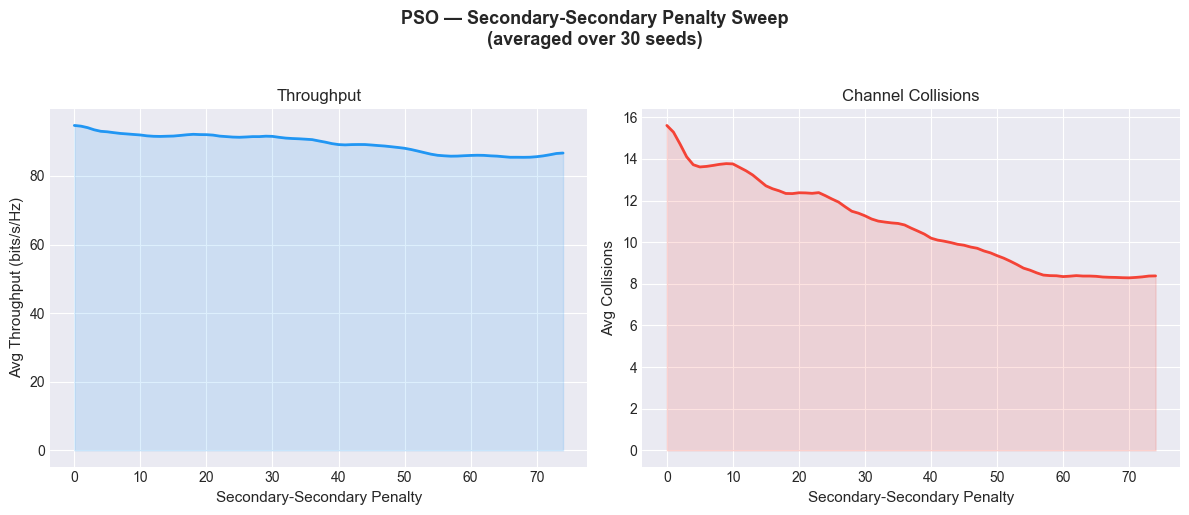

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# Smooth the curves slightly for readability
avg_smooth = uniform_filter1d(avg_throughput, size=5)
avg_dupe_smooth = uniform_filter1d(avg_dupe, size=5)

plt.style.use("seaborn-v0_8-darkgrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("PSO — Secondary-Secondary Penalty Sweep\n(averaged over 30 seeds)", 
             fontsize=13, fontweight="bold", y=1.02)

ss_range = range(n_ss)

# Throughput plot
ax1.plot(ss_range, avg_smooth, color="#2196F3", linewidth=2)
ax1.fill_between(ss_range, avg_smooth, alpha=0.15, color="#2196F3")
ax1.set_xlabel("Secondary-Secondary Penalty", fontsize=11)
ax1.set_ylabel("Avg Throughput (bits/s/Hz)", fontsize=11)
ax1.set_title("Throughput", fontsize=12)

# Duplicates plot
ax2.plot(ss_range, avg_dupe_smooth, color="#F44336", linewidth=2)
ax2.fill_between(ss_range, avg_dupe_smooth, alpha=0.15, color="#F44336")
ax2.set_xlabel("Secondary-Secondary Penalty", fontsize=11)
ax2.set_ylabel("Avg Collisions", fontsize=11)
ax2.set_title("Channel Collisions", fontsize=12)

plt.tight_layout()

plt.show()

QPSO algorithm

In [ ]:
def dqpso(f, D, N, S, n_iter, beta_start, beta_end):

    x = np.random.uniform(0, S, size=(N, D))                            # setting up the initial positions of the N number of particles
    p = x.copy()                                                        # best particle position
    fp = np.array([f(p[i]) for i in range(N)])                          # throughput of all particles
    p_hat = x[np.argmin(fp)].copy()                                     # global best position
    fp_hat = f(p_hat)                                                   # throughput of global best position


    for i in range(n_iter):

        if i%(n_iter//10)== 0:                                          # to show progress
            print(f"progress {(i/n_iter)*100:.0f}%")
        
        
        beta = beta_start - (beta_start - beta_end) * i / n_iter        # Beta decreases linearly from beta_start to beta_end

        mbest = np.mean(p, axis=0)                                      # Mean best position ie average of all personal bests

        phi = np.random.uniform(0,1, (N,D))                             
        p_local = phi * p + (1 - phi) * p_hat                           # local attractor for each particle (works like velocity or inertia)

        u = np.random.uniform(1e-12, 1, (N,D))                           
        sign = 2 * np.random.randint(0, 2, size=(N,D)) - 1
        x = p_local + sign * beta * np.abs(mbest - x) * np.log(1/u)     # calculates the next value of x
        x = np.clip(x, 0, S)                                            # to limit the range within the subspace


        for n in range(N):                                              # calculation for each particle

            xn = x[n]                                                   # getting position of that particle           
            fxn = f(xn)                                                 # current throughput of that particle
            fpn = fp[n]                                                 # best throughput of that particle

            if fxn < fpn:                                               # if current throughput of that particle is better the previous ones, update
                p[n] = xn.copy()
                fp[n] = fxn

                if fxn < fp_hat:                                        # if the current througput is the global best throughput, update
                    p_hat = xn.copy()
                    fp_hat = fxn
    
    print("progress 100%")
    return p_hat                                                        # "coordinates", ie channel allocation of global best throughput

            

    

Calling QPSO

In [ ]:
"""
result_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)

Q_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)

Q_throughput = 0
for user in range(n_users):
    ch = Q_best_assignment[user]
    if not PU_occupied[ch]:
        Q_throughput += np.log2(1 + SINR[user, ch])
"""



'\nresult_qpso = dqpso(fitness, D, N, S, n_iter, beta_start, beta_end)\n\nQ_best_assignment = np.clip(np.round(result_qpso).astype(int), 0, n_channels-1)\n\nQ_throughput = 0\nfor user in range(n_users):\n    ch = Q_best_assignment[user]\n    if not PU_occupied[ch]:\n        Q_throughput += np.log2(1 + SINR[user, ch])\n'

In [ ]:
print("Classical Particle Swarm Optimization\n")
print("Channel assignment:", C_best_assignment)
print("Throughput:", C_throughput)
'''
print("\n\nQuantum Particle Swarm Optimization \n")
print("Channel assignment:", Q_best_assignment)
print("Throughput:", Q_throughput)
'''

Classical Particle Swarm Optimization

Channel assignment: [26  6 17 37 29 31 23 33 21 22  2  9 14 12 25 14 10 23 10 38 28  5 15  3
 11  4 34 37  2 13  7 11  8 31 16]
Throughput: 75.85616224623934


'\nprint("\n\nQuantum Particle Swarm Optimization \n")\nprint("Channel assignment:", Q_best_assignment)\nprint("Throughput:", Q_throughput)\n'